In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from nltk.translate.bleu_score import sentence_bleu

import os

In [2]:
data_path = "../results/colonoscopy_metadata.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (42126, 7)


,source,question,answer,img_id,question_type,question_norm,answer_type
0,Ulcerative Colitis,Are there any abnormalities in the image? Chec...,ulcerative colitis,cla820gl0s3nv071u4fgd7xgq,Yes/No,are there any abnormalities in the image? chec...,Token
1,Ulcerative Colitis,Are there any anatomical landmarks in the imag...,none,cla820gl0s3nv071u4fgd7xgq,Yes/No,are there any anatomical landmarks in the imag...,None/NA
2,Ulcerative Colitis,Are there any instruments in the image? Check ...,none,cla820gl0s3nv071u4fgd7xgq,Yes/No,are there any instruments in the image? check ...,None/NA
3,Ulcerative Colitis,Have all polyps been removed?,not relevant,cla820gl0s3nv071u4fgd7xgq,Yes/No,have all polyps been removed,None/NA
4,Ulcerative Colitis,Is this finding easy to detect?,yes,cla820gl0s3nv071u4fgd7xgq,Yes/No,is this finding easy to detect,Yes/No


In [3]:
uc_df = df[df['source'].str.contains("colitis", case=False, na=False)].copy()

print("Ulcerative Colitis subset:", uc_df.shape)
uc_df.head()

Ulcerative Colitis subset: (16890, 7)


,source,question,answer,img_id,question_type,question_norm,answer_type
0,Ulcerative Colitis,Are there any abnormalities in the image? Chec...,ulcerative colitis,cla820gl0s3nv071u4fgd7xgq,Yes/No,are there any abnormalities in the image? chec...,Token
1,Ulcerative Colitis,Are there any anatomical landmarks in the imag...,none,cla820gl0s3nv071u4fgd7xgq,Yes/No,are there any anatomical landmarks in the imag...,None/NA
2,Ulcerative Colitis,Are there any instruments in the image? Check ...,none,cla820gl0s3nv071u4fgd7xgq,Yes/No,are there any instruments in the image? check ...,None/NA
3,Ulcerative Colitis,Have all polyps been removed?,not relevant,cla820gl0s3nv071u4fgd7xgq,Yes/No,have all polyps been removed,None/NA
4,Ulcerative Colitis,Is this finding easy to detect?,yes,cla820gl0s3nv071u4fgd7xgq,Yes/No,is this finding easy to detect,Yes/No


In [4]:
def map_severity(row):
    text = (str(row['answer']) + " " + str(row['question'])).lower()

    # Severe
    if any(word in text for word in [
        "severe", "bleeding", "hemorrhage", "ulcer", "deep ulcer", "spontaneous bleeding"
    ]):
        return 3

    # Moderate
    elif any(word in text for word in [
        "moderate", "friability", "erosion", "marked erythema", "loss of vascular pattern"
    ]):
        return 2

    # Mild
    elif any(word in text for word in [
        "mild", "erythema", "mild inflammation", "slight vascular pattern loss"
    ]):
        return 1

    # Normal
    else:
        return 0

uc_df['severity'] = uc_df.apply(map_severity, axis=1)
print("Severity distribution:\n", uc_df['severity'].value_counts())

Severity distribution:
 severity
0    15898
3      992
Name: count, dtype: int64


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

uc_df['qa_text'] = uc_df['question'].astype(str) + " " + uc_df['answer'].astype(str)

vectorizer = TfidfVectorizer(max_features=500)
X = vectorizer.fit_transform(uc_df['qa_text'])
y = uc_df['severity']

print("Feature matrix shape:", X.shape, " | Labels distribution:", np.bincount(y))

Feature matrix shape: (16890, 93)  | Labels distribution: [15898     0     0   992]


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (13512, 93)  Test size: (3378, 93)


In [7]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3180
           3       1.00      1.00      1.00       198

    accuracy                           1.00      3378
   macro avg       1.00      1.00      1.00      3378
weighted avg       1.00      1.00      1.00      3378



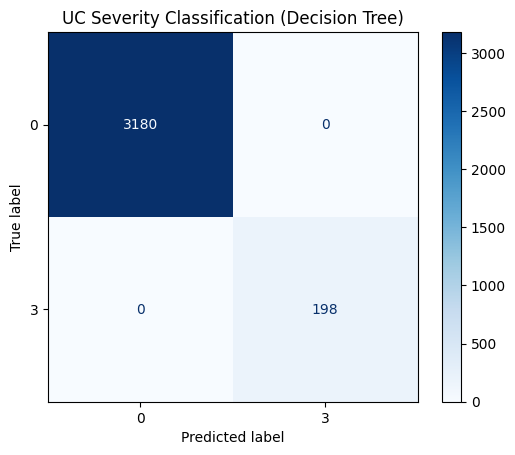

In [8]:
import numpy as np

cm = confusion_matrix(y_test, y_pred)
labels = np.unique(np.concatenate((y_test, y_pred)))  # only classes that exist
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("UC Severity Classification (Decision Tree)")
plt.show()